# All 8 Models — Head-to-Head Comparison

Compares the 4 tabular XGBoost models and the 4 `LineupGNN` variants on the
same target (`xg_team1_minus_team2_per_30`), the **same row subset**, and
now the **same train / test split**. The eight models cover a
**2 × 2 × 2 design**:

| axis | levels |
|---|---|
| model class | tabular (XGBoost) · graph (GNN) |
| personnel kind | raw positions · per-season archetypes |
| opponent in view | ego only · matchup (opponent included) |

Shared partitions (produced by `scripts.build_train_test_split`):
match-blocked 80 / 20 with `seed=0`, saved to
`data/processed/{train,test}_snapshots.parquet`. Every match's home and
away focal-team rows always land in the same partition, and the filter
`features.snapshots.filter_buildable_snapshots` runs first so the rows
are identical to what the GNN dataset consumes (~73.6 k rows total →
~59.1 k train / ~14.5 k test). NaN archetypes are kept in both pipelines:
XGBoost encodes them as the `"MISSING"` category and the GNN's archetype
vocab includes a `"MISSING"` token.

Evaluation:

- **Tabular**: `xgb.XGBRegressor` fit on the train parquet, predicted on
  the test parquet. Metrics are computed once against the test set.
- **GNN**: trained on the train parquet via `scripts.train_gnn`; each
  epoch evaluates against the test parquet. Best-epoch metrics + test
  predictions are read from `artifacts/gnn_<kind>_<mode>/`.

Caveat: this matches the row sets and the validation matches, but the
GNN gets a mild advantage because it sees the test loss every epoch and
picks the best-test checkpoint, while the tabular fit is a single
fixed-budget XGBoost. Add a small inner validation slice if you want
that gap closed.

Plotting helpers live in `models.comparison`; this notebook stays thin.

In [ ]:
from __future__ import annotations
import sys
from pathlib import Path

HERE = Path.cwd()
ROOT = HERE
while ROOT != ROOT.parent and not (ROOT / 'configs' / 'config.yaml').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from models.comparison import (
    MODEL_KEYS,
    ablation_deltas,
    build_summary_table,
    load_gnn_results,
    load_tabular_results,
    plot_metric_bars,
    plot_pred_vs_target_grid,
    plot_residual_hists,
)

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 30)

ARTIFACTS = ROOT / 'artifacts'
TRAIN = ROOT / 'data' / 'processed' / 'train_snapshots.parquet'
TEST  = ROOT / 'data' / 'processed' / 'test_snapshots.parquet'
train_df = pd.read_parquet(TRAIN)
test_df  = pd.read_parquet(TEST)
print(f'train: {len(train_df):,} rows / {train_df["match_id"].nunique():,} matches')
print(f'test:  {len(test_df):,} rows / {test_df["match_id"].nunique():,} matches')

## Load results

Fits each tabular model on the train parquet and predicts on the test
parquet (no CV — one fit, one held-out evaluation). Loads GNN training
logs + best-epoch test predictions from `artifacts/`. Models with no log
file are silently skipped — train them with
`python -m scripts.train_gnn --kind <k> --mode <m>` to bring them in.

In [ ]:
tab_results = load_tabular_results(train_df, test_df)
gnn_results = load_gnn_results(ARTIFACTS)

available = list(tab_results) + list(gnn_results)
missing = [k for k in MODEL_KEYS if k not in available]
print(f'loaded {len(available)} models: {available}')
if missing:
    print(f'missing: {missing}')

## Unified summary table

Every row's metrics come from predictions on the shared held-out test
set. Tabular rows are the single train-fit / test-predict pass; GNN
rows are the best-epoch test metrics from training.

In [3]:
summary = build_summary_table(tab_results, gnn_results)
summary.round(4)

,key,class,kind,opponent,MAE,MAE (std),RMSE,R²,sign acc,eval
model,,,,,,,,,,
tab · pos · ego,tab_pos_ego,tabular,position,ego,0.5709,0.0126,1.0365,0.0140,0.5687,5-fold GroupKFold
tab · pos · matchup,tab_pos_matchup,tabular,position,matchup,0.5834,0.0130,1.0514,-0.0163,0.5653,5-fold GroupKFold
tab · arch · ego,tab_arch_ego,tabular,archetype,ego,0.5912,0.0104,1.0438,-0.0005,0.5678,5-fold GroupKFold
tab · arch · matchup,tab_arch_matchup,tabular,archetype,matchup,0.5844,0.0098,1.0292,0.0277,0.5908,5-fold GroupKFold
gnn · pos · ego,gnn_position_single,graph,position,ego,0.5307,NaN,0.9123,0.0069,0.4488,random 10 % val
gnn · arch · ego,gnn_archetype_single,graph,archetype,ego,0.5427,NaN,0.8591,0.1194,0.6012,random 10 % val
gnn · pos · matchup,gnn_position_paired,graph,position,matchup,0.5312,NaN,0.9130,0.0054,0.4450,random 10 % val
gnn · arch · matchup,gnn_archetype_paired,graph,archetype,matchup,0.5412,NaN,0.8577,0.1222,0.6012,random 10 % val


## Headline metric comparison

Bars colored by `(kind, opponent)` corner; lighter shade is the tabular
model, darker shade is its GNN counterpart at the same corner. All
metrics on the shared held-out test set.

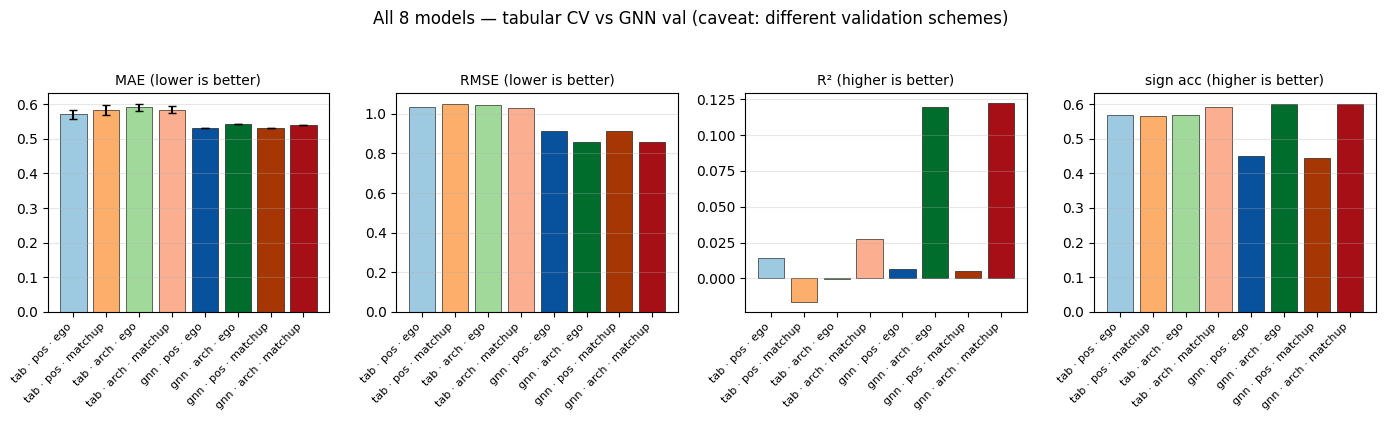

In [4]:
fig = plot_metric_bars(summary); plt.show()

## Predictions vs targets (held-out test set)

Both pipelines predict on the exact same ~14.5k test rows. Top row:
tabular (XGBoost) predictions. Bottom row: GNN best-epoch test
predictions. Columns are the `(kind, opponent)` corners. Pearson `r`
summarises rank-consistency between predictions and observed
differentials.

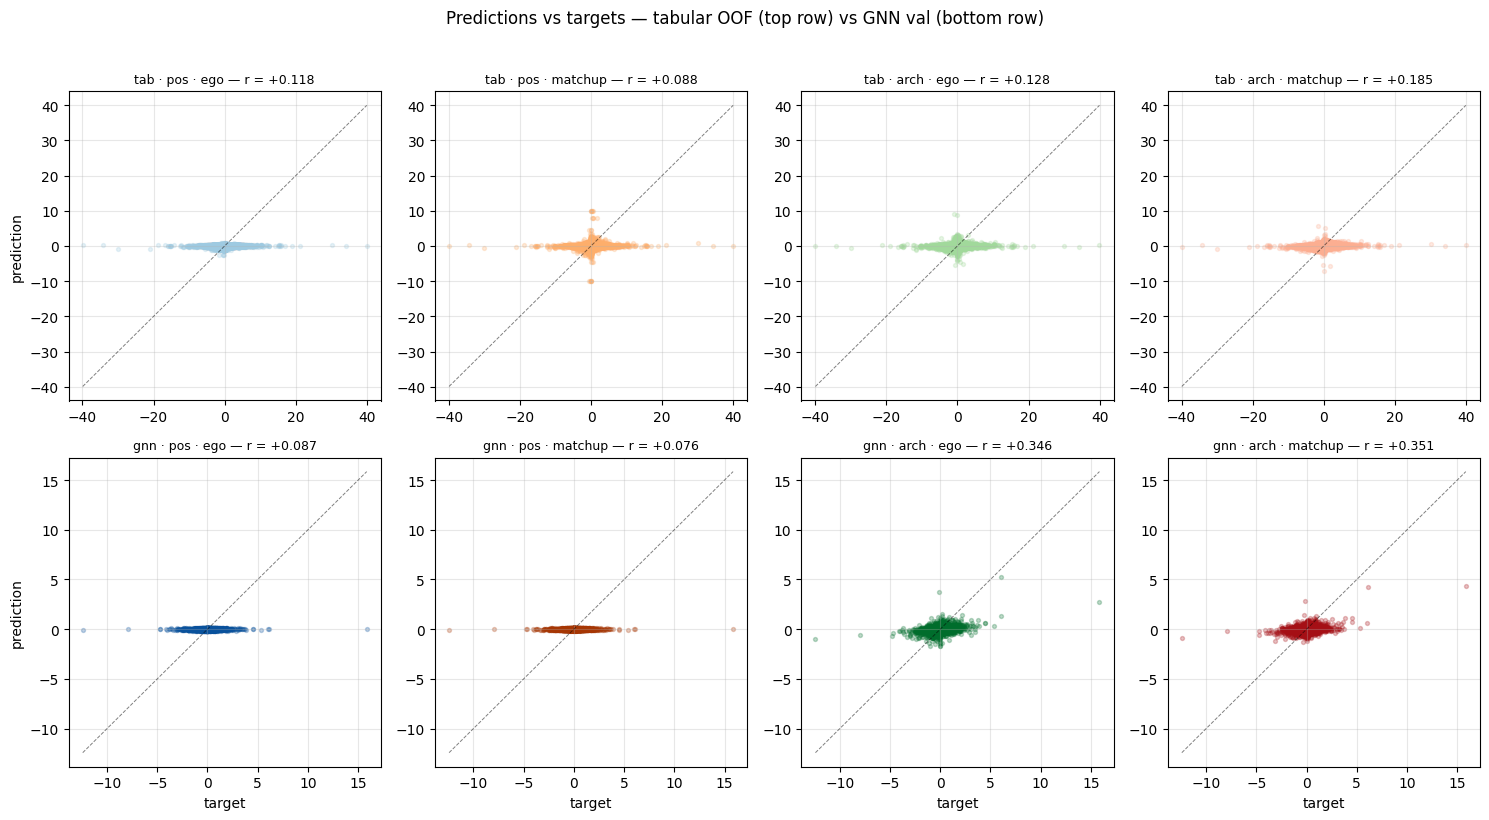

In [5]:
fig = plot_pred_vs_target_grid(tab_results, gnn_results); plt.show()

## Residual distributions (held-out test set)

`pred − target` on the shared test set for each model. The mean (μ)
flags systematic bias; the spread (σ) is an MSE-free read on how
concentrated the errors are.

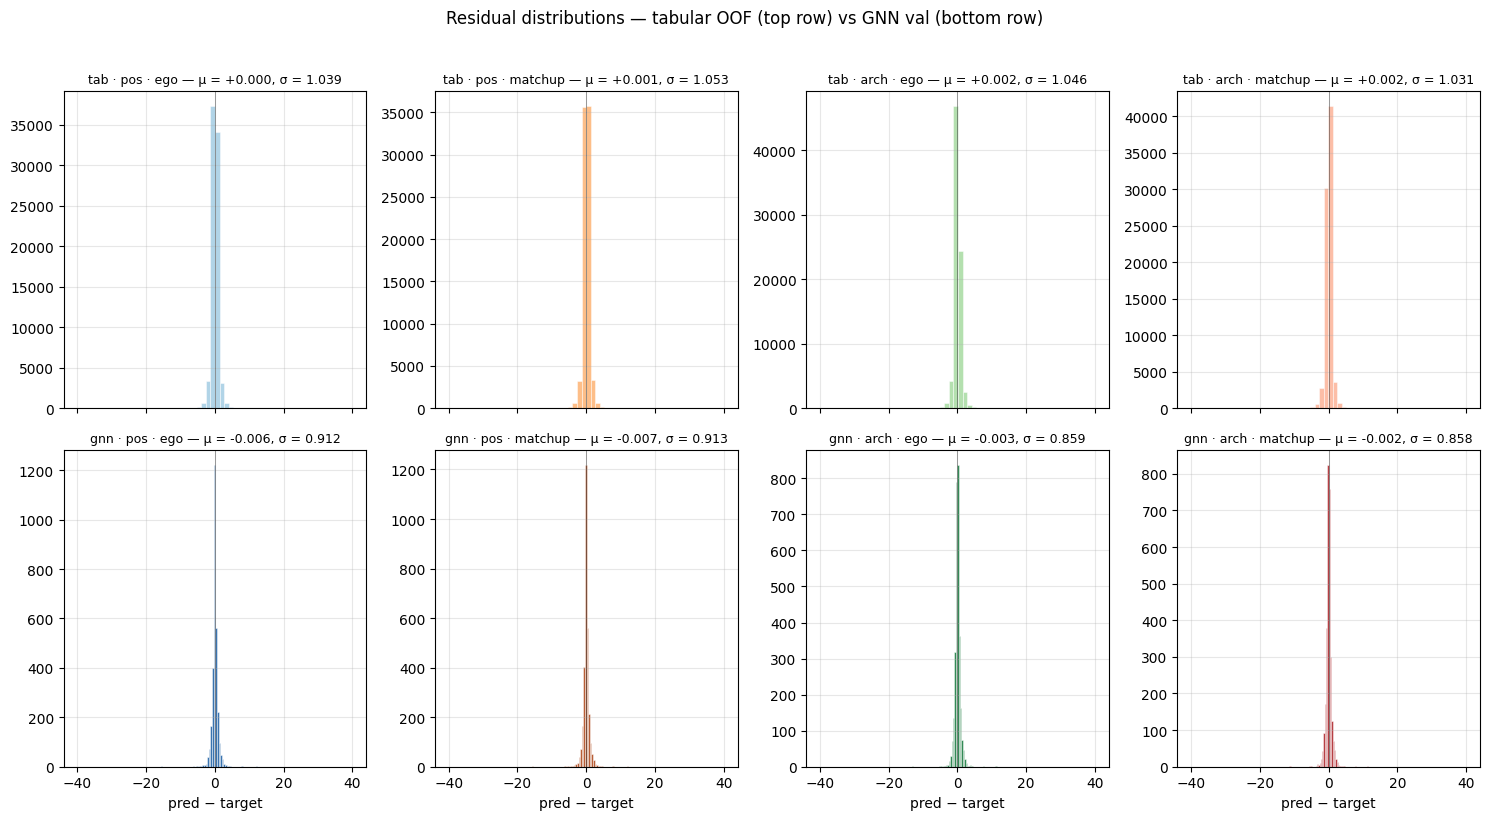

In [6]:
fig = plot_residual_hists(tab_results, gnn_results); plt.show()

## Pairwise ablation deltas

Each row isolates one design axis at one fixed corner of the other two
axes. `Δ MAE` and `Δ RMSE` are negative when the second model (the `to`
column) is better; `Δ R²` and `Δ sign acc` are positive when better.

Three axes:

- **tabular → graph**: does the graph architecture add signal at each `(kind, opponent)` corner?
- **position → archetype**: does archetype enrichment help, holding model class + opponent?
- **ego → matchup**: does including the opponent help, holding model class + kind?

In [7]:
ablation_deltas(summary)

,axis,comparison,from,to,Δ MAE,Δ RMSE,Δ R²,Δ sign acc
0,tabular → graph,pos / ego,tab · pos · ego,gnn · pos · ego,-0.0402,-0.1242,-0.0071,-0.1199
1,tabular → graph,pos / matchup,tab · pos · matchup,gnn · pos · matchup,-0.0522,-0.1383,0.0216,-0.1203
2,tabular → graph,arch / ego,tab · arch · ego,gnn · arch · ego,-0.0485,-0.1847,0.1199,0.0333
3,tabular → graph,arch / matchup,tab · arch · matchup,gnn · arch · matchup,-0.0432,-0.1715,0.0945,0.0104
4,position → archetype,tabular / ego,tab · pos · ego,tab · arch · ego,0.0203,0.0073,-0.0144,-0.0009
5,position → archetype,tabular / matchup,tab · pos · matchup,tab · arch · matchup,0.0010,-0.0222,0.0439,0.0255
6,position → archetype,graph / ego,gnn · pos · ego,gnn · arch · ego,0.0120,-0.0532,0.1125,0.1523
7,position → archetype,graph / matchup,gnn · pos · matchup,gnn · arch · matchup,0.0100,-0.0553,0.1168,0.1562
8,ego → matchup,tabular / pos,tab · pos · ego,tab · pos · matchup,0.0125,0.0148,-0.0302,-0.0034
9,ego → matchup,tabular / arch,tab · arch · ego,tab · arch · matchup,-0.0068,-0.0146,0.0281,0.0229
